In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch 
from tqdm.auto import tqdm
import matplotlib.pyplot as plt 

In [3]:
from modules import * 
from visuals import *

In [4]:
import sys, os, json
DIR = "/Users/knv2/Documents/codebase/AFL-tutorial/3DPhaseDiagram"
folders = [DIR + "/modules/", DIR + "/dataset/", DIR + "/benchmarking/"]
for path in folders:
    if path not in sys.path:
        sys.path.append(path)

from helpers import get_simulator
from evaluate import get_boundaries_geodesic_distance

In [5]:
sim = get_simulator(DIR + "/dataset/")

In [6]:
def oracle(xy, t):
    labels = []
    for ti in t:
        ds = sim.simple_expose(
            {'protein':xy.numpy()[0],
            'temperature':ti.numpy().item(),
            'glycerol':xy.numpy()[1]
        })
        labels.append(int(ds.attrs['labels']))
    return torch.tensor(labels).to(xy)

In [7]:
bounds = torch.tensor(
    [
        [0.0, 80.0], 
        [0.0, 12.0],
        [0.0, 50.0]
    ]
    ).T

bounds_c = bounds.clone()[:,:2]
bounds_t = bounds.clone()[:,-1]

In [8]:
n_init = 2 
n_init_temps = 5
train_X, train_Y = generate_random_samples(oracle, n_init, bounds_c, n_init_temps, bounds_t)

In [9]:
from gpytorch.likelihoods import DirichletClassificationLikelihood
from botorch.models.transforms import Normalize

likelihood = DirichletClassificationLikelihood(
    train_Y.long().squeeze(), 
    learn_additional_noise=True
)
model = DirichletGPModel(
    train_X, 
    likelihood.transformed_targets, 
    likelihood, 
    num_classes = likelihood.num_classes,
    transform = Normalize(d=3, bounds = bounds)
    )

model, likelihood = fit_dirchlet_gp(train_X, model, likelihood, n_iterations=100)

Fitting GP Model:   0%|          | 0/100 [00:00<?, ?it/s]

In [10]:
grid_xy, grid_t, grid_xyz = make_grid_point_cloud(bounds_c, bounds_t, nx=10, ny=10, nz=25)

In [11]:
ground_truth_labels = torch.cat([oracle(xyz[:2], xyz[-1].reshape(-1,1)) for xyz in grid_xyz])

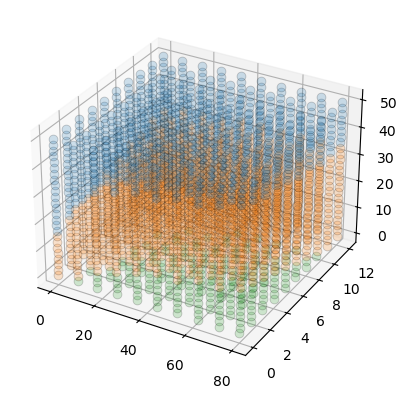

In [12]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection="3d")
for l in ground_truth_labels.unique():
    flags = ground_truth_labels==l
    ax.scatter(
        grid_xyz[flags, 0], 
        grid_xyz[flags, 1], 
        grid_xyz[flags, 2],
        s=40,
        depthshade=False,
        edgecolors="k",
        linewidths=0.6,
        alpha=0.2,
        zorder=4,
    )
plt.show()

(tensor([1, 1, 1,  ..., 0, 0, 0]),
 <Figure size 640x480 with 3 Axes>,
 [<Axes3D: title={'center': 'Accuracy 0.81'}>, <Axes3D: >])

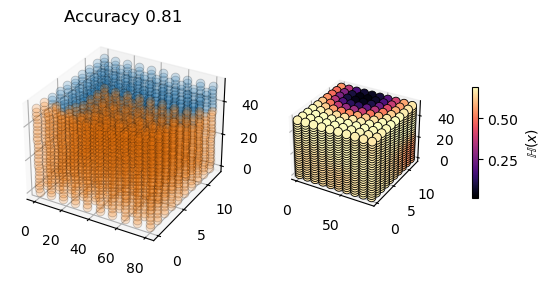

In [19]:
plot_model_posterior(model, grid_xyz, ground_truth_labels)

In [20]:
manifold = SRSFHilbertSphere(sampling_points=100, ambient_dim=1)

Optimizing XY:   0%|          | 0/100 [00:00<?, ?it/s]

(<Figure size 640x480 with 2 Axes>, <Axes: >)

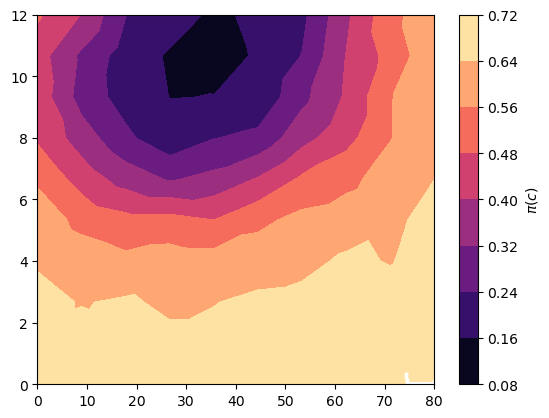

In [21]:
# optimize composition space in R^2
acqf = lambda X: batch_acqusition_xy(X, model, manifold, bounds_t, n_samples=16)
xy_star, trajectory_xy = optimize_xy(bounds_c, acqf, n_iterations=100)
plot_xy_optimization(acqf, grid_xy, xy_star, trajectory_xy)

Optimizing q:   0%|          | 0/50 [00:00<?, ?it/s]

<Axes: xlabel='Time', ylabel='Temperature'>

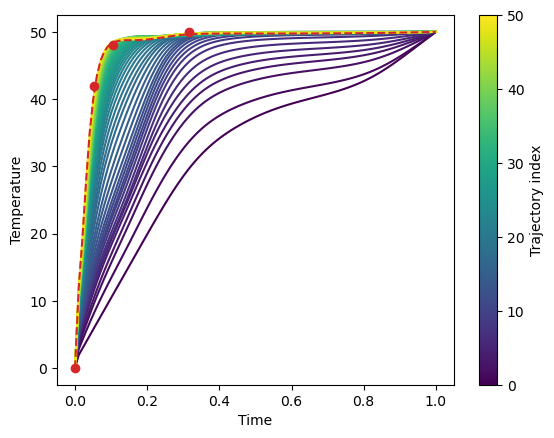

In [22]:
# optimize temperature profile in S_{\inf}
q_star, f_star, trajectory_f, loss_traj_f, ind_f = optimize_f(model, manifold, xy_star, bounds_t)
profile = get_temperature_profile(f_star, bounds_t)
temperatures = profile.fx.reshape(-1,1)
plot_function_optimization(manifold, profile, trajectory_f[ind_f,...], bounds_t)

(<Figure size 640x480 with 1 Axes>, <Axes3D: >)

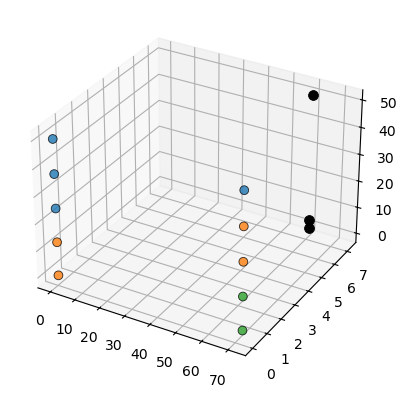

In [ ]:
plot_active_learning_data(train_X, train_Y, xy_star, temperatures)

In [ ]:
# update dataset
new_Y = oracle(xy_star.squeeze(), temperatures)
xy_star_expanded = xy_star.view(-1, 1, 2).expand(-1, len(temperatures), -1).squeeze(0)
new_X = torch.cat([xy_star_expanded.squeeze(), temperatures], dim=1)

train_X = torch.cat((train_X, new_X))
train_Y = torch.cat((train_Y, new_Y.reshape(-1, 1)))

In [ ]:
import yaml 
with open("./config.yaml") as stream:
    cfg = yaml.safe_load(stream)
cfg

{'n_iterations': 10,
 'n_init': 2,
 'n_init_temps': 5,
 'save_path': './results/',
 'gp': {'n_iterations': 100},
 'optimize_xy': {'n_samples': 16, 'n_iterations': 200, 'n_restarts': 16},
 'optimize_f': {'n_iterations': 100, 'n_restarts': 16, 'dt': 0.5, 'dT': 3.0}}

Active Learning:   0%|          | 0/10 [00:00<?, ?it/s]

Fitting GP Model:   0%|          | 0/100 [00:00<?, ?it/s]

/Users/knv2/Documents/codebase/envs/3DPhaseDiag/lib/python3.11/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


Optimizing XY:   0%|          | 0/100 [00:00<?, ?it/s]

Optimizing q:   0%|          | 0/50 [00:00<?, ?it/s]

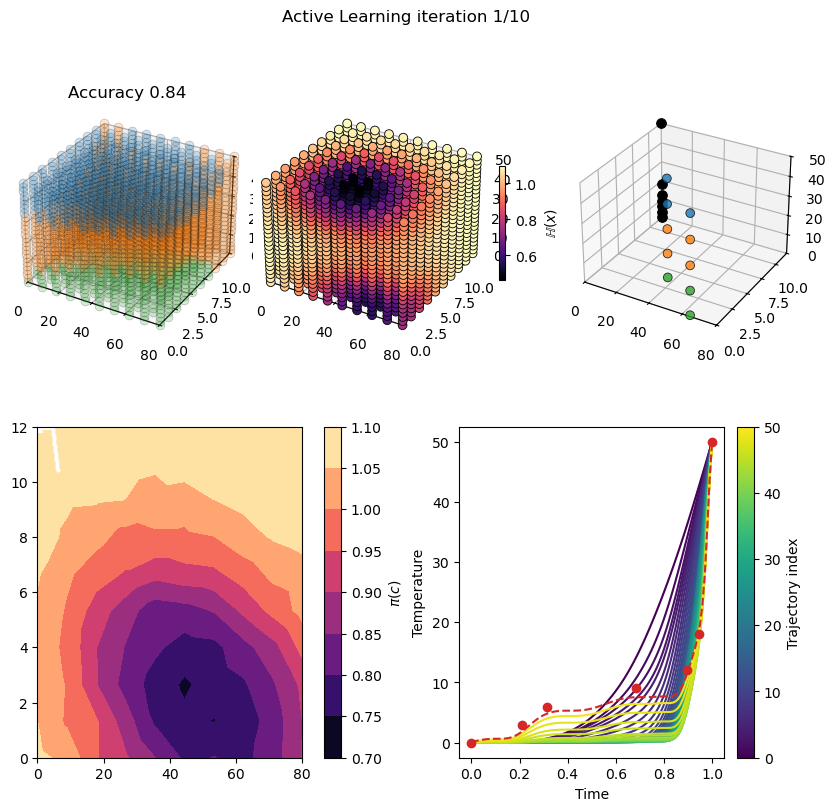

Fitting GP Model:   0%|          | 0/100 [00:00<?, ?it/s]

/Users/knv2/Documents/codebase/envs/3DPhaseDiag/lib/python3.11/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


Optimizing XY:   0%|          | 0/100 [00:00<?, ?it/s]

Optimizing q:   0%|          | 0/50 [00:00<?, ?it/s]

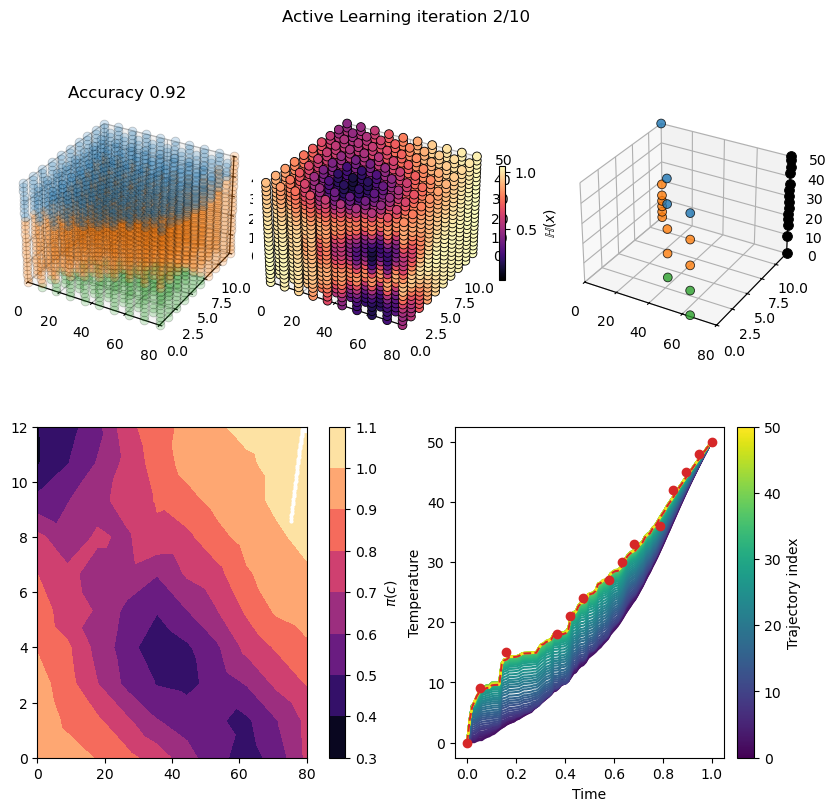

Fitting GP Model:   0%|          | 0/100 [00:00<?, ?it/s]

/Users/knv2/Documents/codebase/envs/3DPhaseDiag/lib/python3.11/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


Optimizing XY:   0%|          | 0/100 [00:00<?, ?it/s]

Optimizing q:   0%|          | 0/50 [00:00<?, ?it/s]

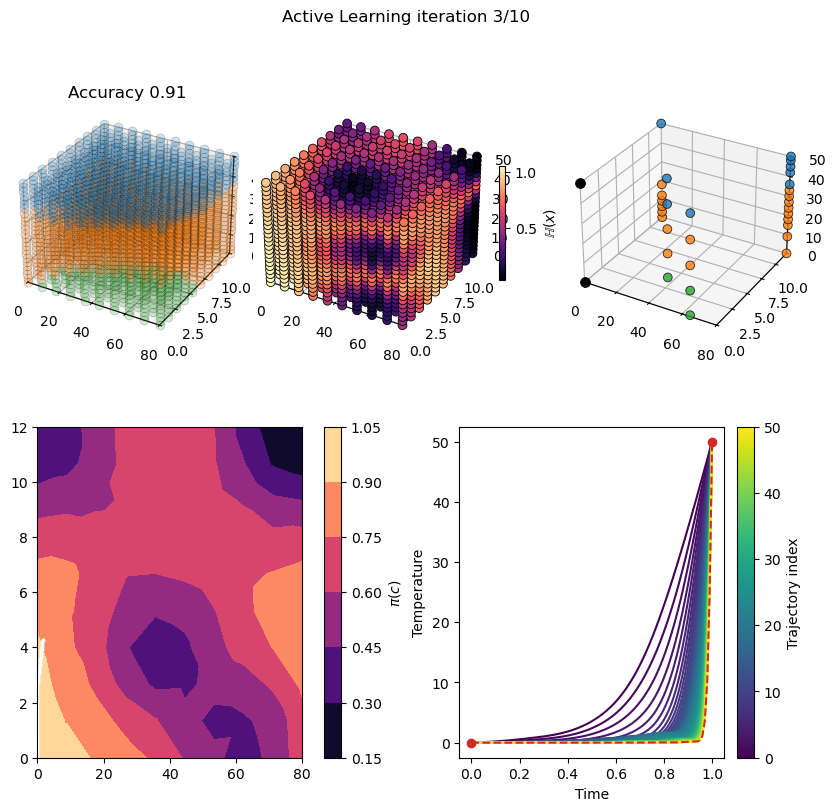

Fitting GP Model:   0%|          | 0/100 [00:00<?, ?it/s]

/Users/knv2/Documents/codebase/envs/3DPhaseDiag/lib/python3.11/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


Optimizing XY:   0%|          | 0/100 [00:00<?, ?it/s]

Optimizing q:   0%|          | 0/50 [00:00<?, ?it/s]

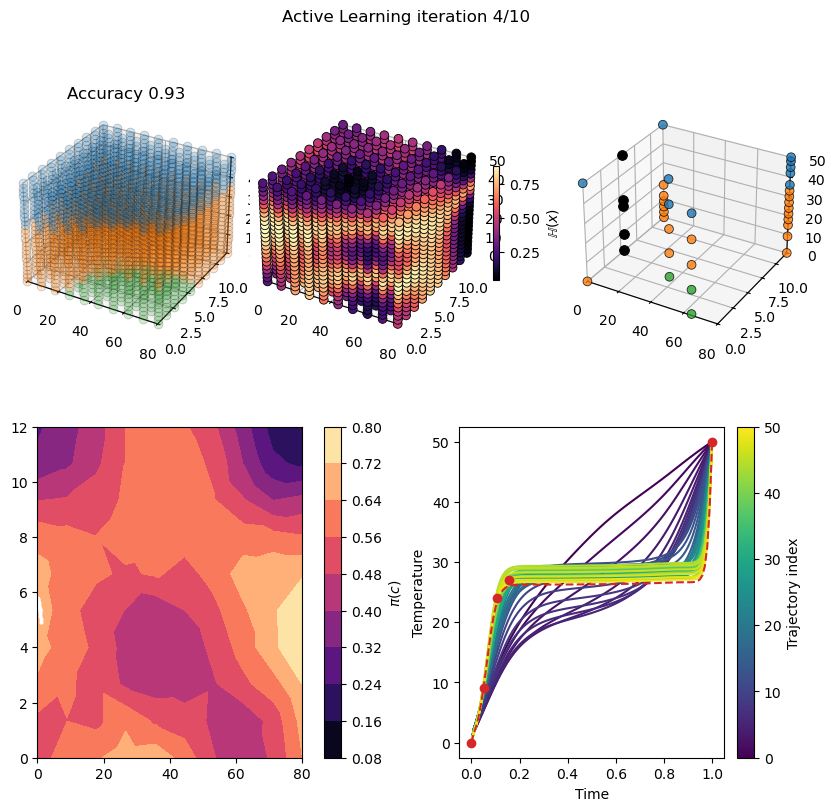

Fitting GP Model:   0%|          | 0/100 [00:00<?, ?it/s]

/Users/knv2/Documents/codebase/envs/3DPhaseDiag/lib/python3.11/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


Optimizing XY:   0%|          | 0/100 [00:00<?, ?it/s]

Optimizing q:   0%|          | 0/50 [00:00<?, ?it/s]

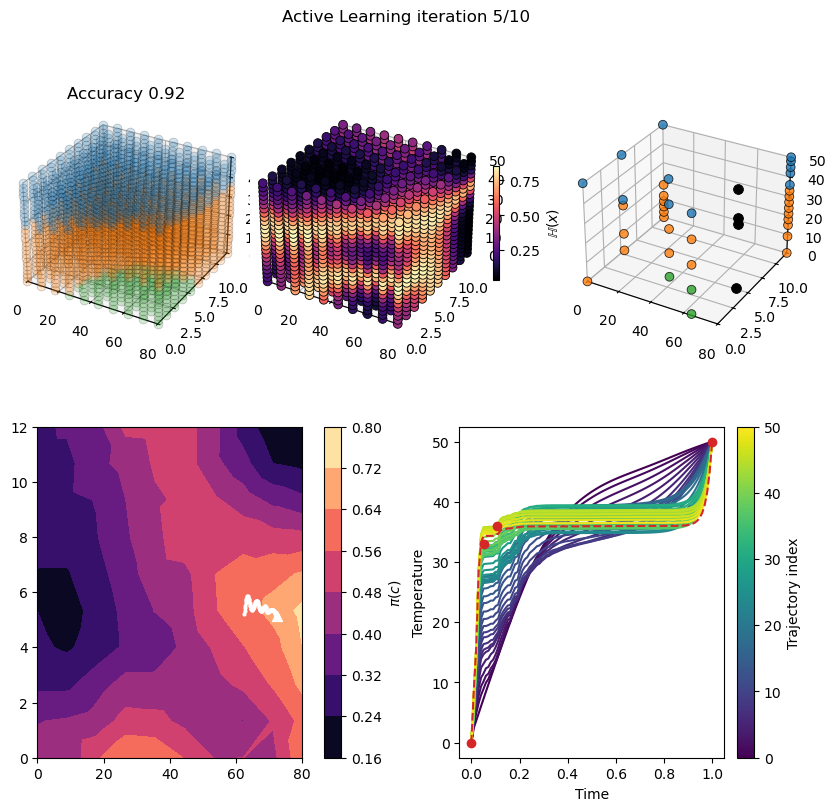

Fitting GP Model:   0%|          | 0/100 [00:00<?, ?it/s]

/Users/knv2/Documents/codebase/envs/3DPhaseDiag/lib/python3.11/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


Optimizing XY:   0%|          | 0/100 [00:00<?, ?it/s]

Optimizing q:   0%|          | 0/50 [00:00<?, ?it/s]

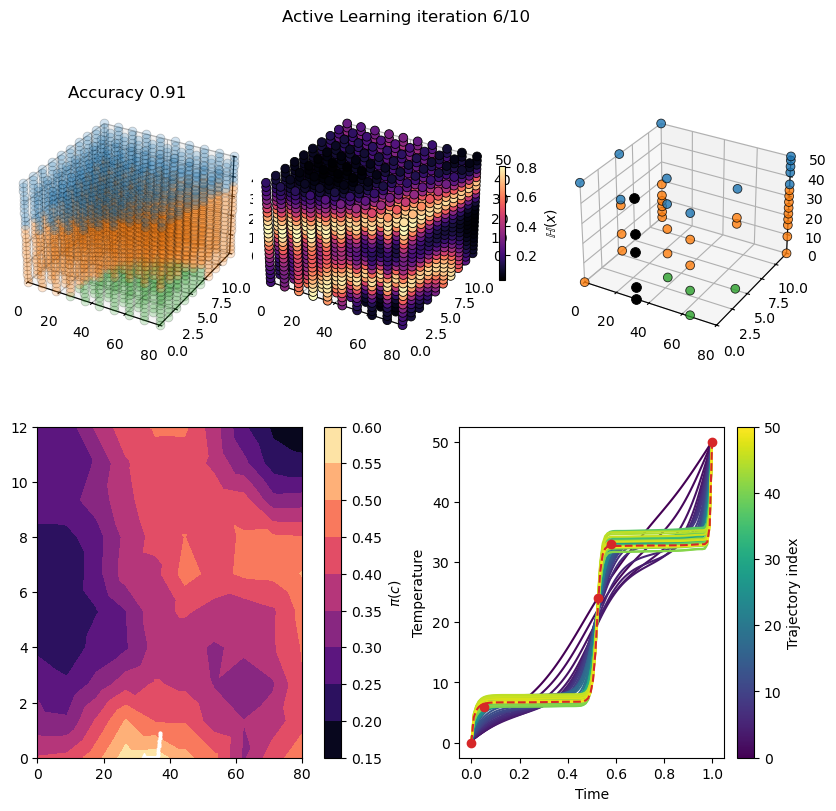

Fitting GP Model:   0%|          | 0/100 [00:00<?, ?it/s]

/Users/knv2/Documents/codebase/envs/3DPhaseDiag/lib/python3.11/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


Optimizing XY:   0%|          | 0/100 [00:00<?, ?it/s]

Optimizing q:   0%|          | 0/50 [00:00<?, ?it/s]

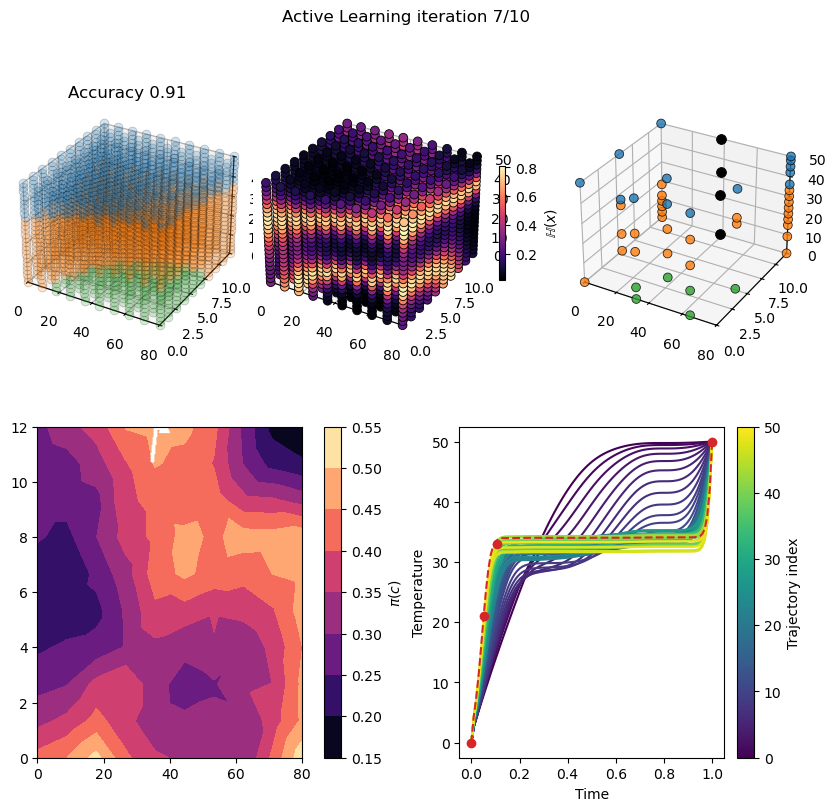

Fitting GP Model:   0%|          | 0/100 [00:00<?, ?it/s]

/Users/knv2/Documents/codebase/envs/3DPhaseDiag/lib/python3.11/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


Optimizing XY:   0%|          | 0/100 [00:00<?, ?it/s]

Optimizing q:   0%|          | 0/50 [00:00<?, ?it/s]

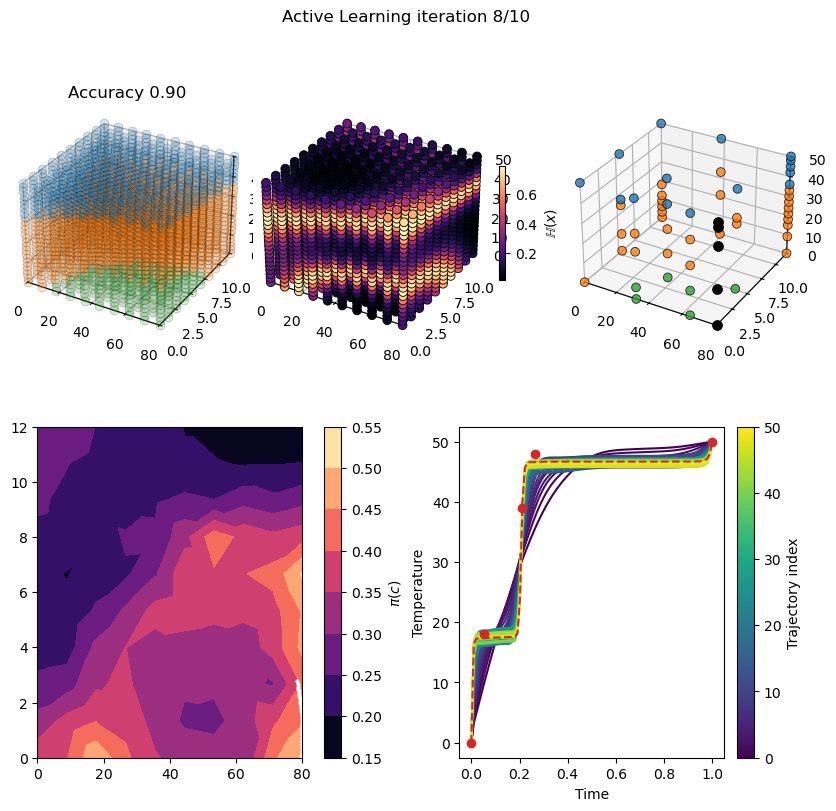

Fitting GP Model:   0%|          | 0/100 [00:00<?, ?it/s]

/Users/knv2/Documents/codebase/envs/3DPhaseDiag/lib/python3.11/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


Optimizing XY:   0%|          | 0/100 [00:00<?, ?it/s]

Optimizing q:   0%|          | 0/50 [00:00<?, ?it/s]

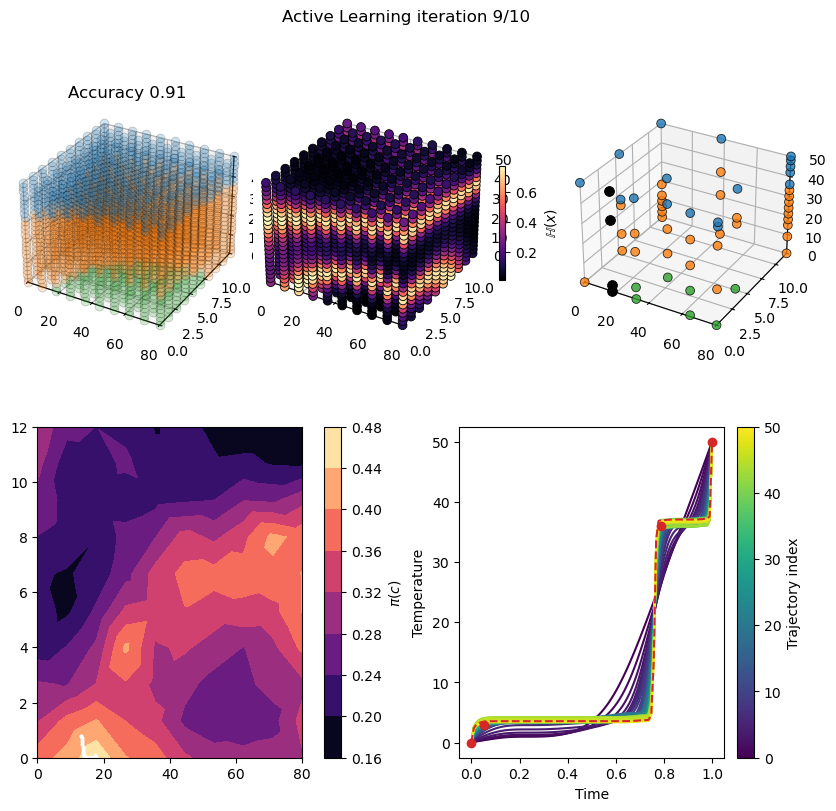

Fitting GP Model:   0%|          | 0/100 [00:00<?, ?it/s]

/Users/knv2/Documents/codebase/envs/3DPhaseDiag/lib/python3.11/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


Optimizing XY:   0%|          | 0/100 [00:00<?, ?it/s]

Optimizing q:   0%|          | 0/50 [00:00<?, ?it/s]

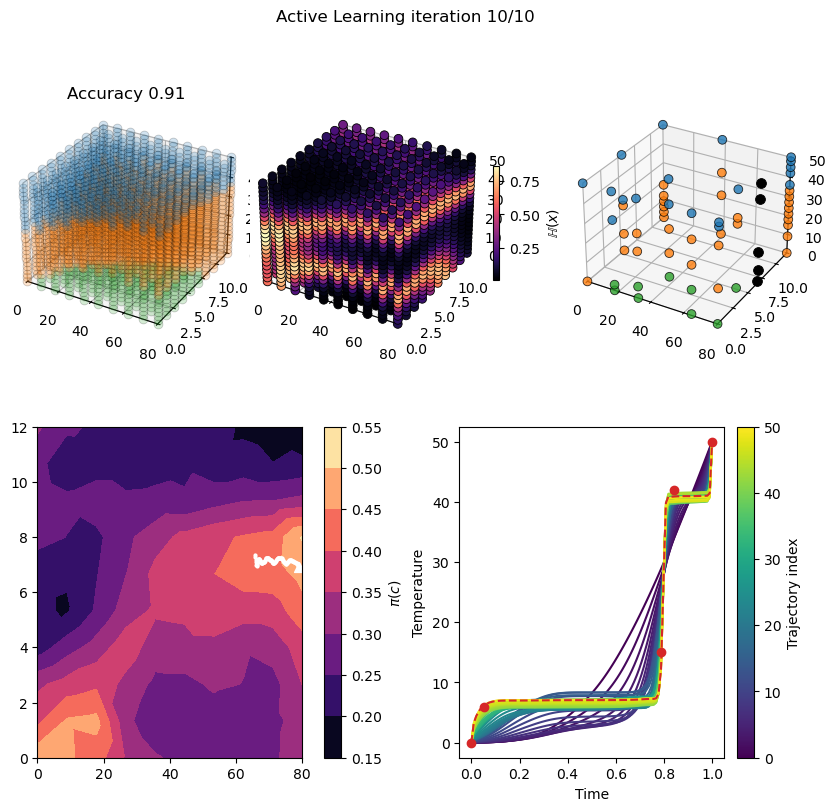

In [ ]:
from pathlib import Path
n_iterations = cfg["n_iterations"]
n_init = cfg["n_init"]
n_init_temps = cfg["n_init_temps"]
train_X, train_Y = generate_random_samples(oracle, n_init, bounds_c, n_init_temps, bounds_t)
batch_sample_indx = torch.zeros(int(n_init*n_init_temps))
pbar = tqdm(range(n_iterations), desc="Active Learning")
dists_file_json = Path(cfg["save_path"]).resolve() /f"dists.json"
if os.path.isfile(dists_file_json):
    os.remove(dists_file_json)

for i in pbar:
    fig, axs = make_gridspec(bounds)
    likelihood = DirichletClassificationLikelihood(
        train_Y.long().squeeze(), 
        learn_additional_noise=True
    )
    model = DirichletGPModel(
        train_X, 
        likelihood.transformed_targets, 
        likelihood, 
        num_classes = likelihood.num_classes,
        transform = Normalize(d=3, bounds = bounds)
        )
    model, likelihood = fit_dirchlet_gp(train_X, model, likelihood, n_iterations=cfg["gp"]["n_iterations"])
    grid_labels, _, _ = plot_model_posterior(model, grid_xyz, ground_truth_labels, ax=[axs[0][0], axs[0][1]])
    
    # optimize composition space in R^2
    acqf = lambda X: batch_acqusition_xy(X, model, manifold, bounds_t, n_samples=cfg["optimize_xy"]["n_samples"])
    xy_star, trajectory_xy = optimize_xy(
        bounds_c, acqf, n_iterations=cfg["optimize_xy"]["n_iterations"], n_restarts=cfg["optimize_xy"]["n_restarts"]
        )
    plot_xy_optimization(acqf, grid_xy, xy_star, trajectory_xy, ax=axs[1][0])
    
    # optimize temperature profile in S_{\inf}
    q_star, f_star, trajectory_f, loss_traj_f, ind_f = optimize_f(
        model, manifold, xy_star, bounds_t, n_iterations=cfg["optimize_f"]["n_iterations"], n_restarts=cfg["optimize_f"]["n_restarts"]
        )
    profile = get_temperature_profile(
        f_star, bounds_t, dt=cfg["optimize_f"]["dt"], dT=cfg["optimize_f"]["dT"]
        )
    temperatures = profile.fx.reshape(-1,1)
    plot_function_optimization(manifold, profile, trajectory_f[ind_f,...], bounds_t, ax=axs[1][1])
    
    plot_active_learning_data(train_X, train_Y, xy_star, temperatures, ax=axs[0][2])

    # update dataset
    new_Y = oracle(xy_star.squeeze(), temperatures)
    xy_star_expanded = xy_star.view(-1, 1, 2).expand(-1, len(temperatures), -1).squeeze(0)
    new_X = torch.cat([xy_star_expanded.squeeze(), temperatures], dim=1)
    
    train_X = torch.cat((train_X, new_X))
    train_Y = torch.cat((train_Y, new_Y.reshape(-1, 1)))
    batch_sample_indx = torch.cat([batch_sample_indx, (i+1)*torch.ones(new_X.shape[0])], dim=0)
    fig.suptitle(f"Active Learning iteration {i+1}/{n_iterations}")
    plt.show()

    # Save distances
    dists = get_boundaries_geodesic_distance(grid_xyz.numpy(), grid_labels.numpy(), make_animation=False)
    with open(dists_file_json, "a") as f:
        f.write(json.dumps({str(k): v for k, v in dists.items()}) + "\n")
        f.flush()

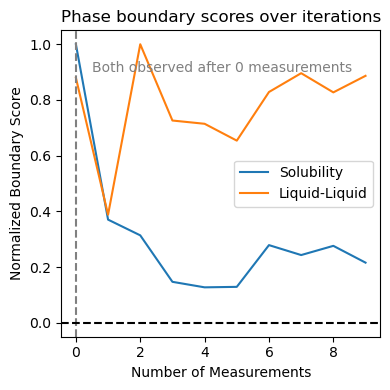

In [ ]:
import ast 

def plot_geodesic_progress(file):
    baselines = {}
    baselines[(0,1)] = 40.0
    baselines[(1,2)] = 15.0
    # --- Load data ---
    records = []
    with open(file, "r") as f:
        for line in f:
            line = line.strip()
            if line:  # skip empty lines
                records.append(json.loads(line))

    # --- Extract phase boundary keys dynamically ---
    keys = sorted(list(records[0].keys()))
    iterations = np.arange(len(records))
    measurements = np.asarray(iterations)

    # Convert data into arrays with None -> np.nan
    data = {k: np.array([r.get(k, None) for r in records], dtype=float) for k in keys}

    # --- Valid mask for both curves existing ---
    valid_mask = np.isfinite(data[keys[0]]) & np.isfinite(data[keys[1]])

    # --- First iteration where both exist till the end ---
    first_both_idx = None
    for idx in range(len(valid_mask)):
        if np.all(valid_mask[idx:]):
            first_both_idx = idx
            break

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(4, 4))

    color1 = "tab:blue"
    color2 = "tab:orange"

    # Plot first boundary (shifted by baseline)
    y = data[keys[0]] - baselines[ast.literal_eval(keys[0])]
    ax.plot(measurements, 
             y/np.nanmax(y),
             color=color1, 
             label="Solubility"
        )
    ax.set_xlabel("Number of Measurements")
    ax.set_ylabel(f"Normalized Boundary Score")

    y = data[keys[1]] - baselines[ast.literal_eval(keys[1])]
    ax.plot(measurements, 
             y/np.nanmax(y),
             color=color2, 
             label="Liquid-Liquid"
        )

    # Vertical line: first iteration where both boundaries are observed till end
    if first_both_idx is not None:
        ax.axvline(measurements[first_both_idx], color="grey", linestyle="--", lw=1.5)
        ax.text(measurements[first_both_idx] + 0.5, ax.get_ylim()[1]*0.9,
                 f"Both observed after {measurements[first_both_idx]} measurements",
                 rotation=0, va="top", color="grey")

    # Baseline lines
    ax.axhline(0.0, color="k", linestyle="--", lw=1.5)
    ax.legend()

    plt.title("Phase boundary scores over iterations")
    fig.tight_layout()
    plt.show()

plot_geodesic_progress("./dists.json")